In [1]:
from google.colab import files
uploaded = files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Token successfully uploaded and moved!")

Saving kaggle.json to kaggle.json
Token successfully uploaded and moved!


In [2]:
!unzip -q us-accidents.zip
print("Unzip complete!")

unzip:  cannot find or open us-accidents.zip, us-accidents.zip.zip or us-accidents.zip.ZIP.
Unzip complete!


In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d sobhanmoosavi/us-accidents
!unzip -q us-accidents.zip
print("Data is back and unzipped!")

Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
License(s): CC-BY-NC-SA-4.0
100% 653M/653M [00:03<00:00, 178MB/s]

Data is back and unzipped!


In [5]:
import pandas as pd
import numpy as np
import random

p = 0.065
file_path = 'US_Accidents_March23.csv'

df = pd.read_csv(
    file_path,
    skiprows=lambda i: i > 0 and random.random() > p,
    low_memory=False
)

if len(df) > 500000:
    df = df.sample(n=500000, random_state=42)

# Cleanup steps
columns_to_drop = ['ID', 'Source', 'Description', 'Street', 'City', 'County', 'Zipcode', 'Timezone', 'Airport_Code', 'Weather_Timestamp']
df = df.drop(columns=columns_to_drop, axis=1)
df['Sunrise_Sunset'] = df['Sunrise_Sunset'].map({'Day': 1, 'Night': 0})
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
cat_cols = df.select_dtypes(include=['object', 'bool']).columns
df[cat_cols] = df[cat_cols].fillna('Unknown')
df = pd.get_dummies(df, columns=['State', 'Weather_Condition'], drop_first=True)
df = df.select_dtypes(exclude=['object'])

print("Data loaded and cleaned! Ready for modeling.")

Data loaded and cleaned! Ready for modeling.


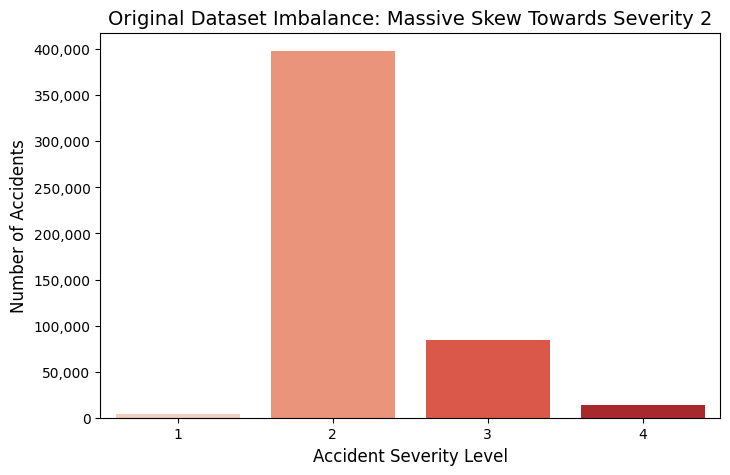

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
# Using the original 'y' dataset before any SMOTE was applied
sns.countplot(x=y, palette='Reds')
plt.title('Original Dataset Imbalance: Massive Skew Towards Severity 2', fontsize=14)
plt.xlabel('Accident Severity Level', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)

# Add commas to the y-axis numbers to make it look professional
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import gc

print("Splitting the data...")
# Separate the target (Severity) from the features
X = df.drop('Severity', axis=1)
y = df['Severity']

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nApplying SMOTE... this creates synthetic data to balance the classes.")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Clean up memory
del X_train
del y_train
gc.collect()

print("\nReady for model training! (You can run the next cell now)")

Splitting the data...

Applying SMOTE... this creates synthetic data to balance the classes.

Ready for model training! (You can run the next cell now)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# Because XGBoost expects classes to start at 0, we temporarily subtract 1 from Severity
y_train_xgb = y_train_smote - 1
y_test_xgb = y_test - 1

# --- 1. Logistic Regression ---
print("\n--- 1. Logistic Regression ---")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_smote, y_train_smote)
lr_preds = lr.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")

# --- 2. Random Forest ---
print("\n--- 2. Random Forest ---")
# n_estimators=50 to keep it fast for this initial run
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_train_smote, y_train_smote)
rf_preds = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")



--- 1. Logistic Regression ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.6061

--- 2. Random Forest ---
Accuracy: 0.8291


In [8]:
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

print("\n--- 3. XGBoost (Updated Syntax) ---")

xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    tree_method='hist',  # Changed from 'gpu_hist'
    device='cuda',       # New command to trigger the GPU
    n_jobs=-1
)

# Train and predict
xgb.fit(X_train_smote, y_train_xgb)
xgb_preds = xgb.predict(X_test) + 1 # Add 1 back to match original Severity 1-4

print(f"Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")


--- 3. XGBoost (Updated Syntax) ---
Accuracy: 0.8042


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

def evaluate_model(model_name, y_true, y_pred, y_probs):
    print(f"\n{'='*50}")
    print(f"--- {model_name} Evaluation ---")
    print(f"{'='*50}")

    # 1. Precision, Recall, and F1-Score (Classification Report)
    print("\n1. Classification Report (Precision, Recall, F1-Score):")
    print(classification_report(y_true, y_pred))

    # 2. AUC-ROC Score (multi_class='ovr' handles our 4 Severity levels)
    auc = roc_auc_score(y_true, y_probs, multi_class='ovr')
    print(f"2. AUC-ROC Score: {auc:.4f}\n")

    # 3. Confusion Matrix
    print("3. Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Sev 1', 'Sev 2', 'Sev 3', 'Sev 4'],
                yticklabels=['Sev 1', 'Sev 2', 'Sev 3', 'Sev 4'])
    plt.title(f"Confusion Matrix: {model_name}")
    plt.ylabel('Actual Severity')
    plt.xlabel('Predicted Severity')
    plt.show()

print("Evaluator function is ready!")

Evaluator function is ready!


Training Decision Tree...

--- Decision Tree Evaluation ---

1. Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           1       0.15      0.27      0.20       878
           2       0.89      0.83      0.86     79684
           3       0.51      0.59      0.55     16810
           4       0.17      0.29      0.21      2628

    accuracy                           0.77    100000
   macro avg       0.43      0.50      0.45    100000
weighted avg       0.80      0.77      0.78    100000

2. AUC-ROC Score: 0.6762

3. Confusion Matrix:


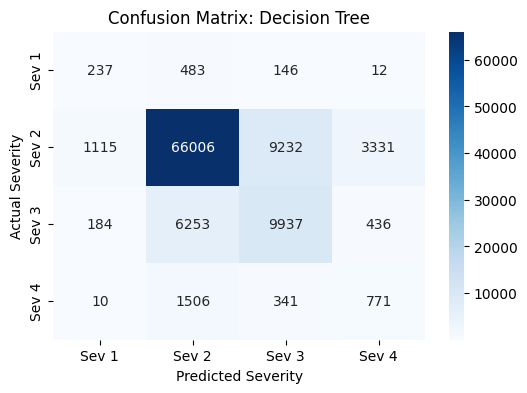


Training Gaussian Naive Bayes...

--- Gaussian Naive Bayes Evaluation ---

1. Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           1       0.01      0.97      0.02       878
           2       0.95      0.01      0.01     79684
           3       0.36      0.13      0.19     16810
           4       0.06      0.20      0.09      2628

    accuracy                           0.04    100000
   macro avg       0.35      0.33      0.08    100000
weighted avg       0.82      0.04      0.05    100000

2. AUC-ROC Score: 0.5936

3. Confusion Matrix:


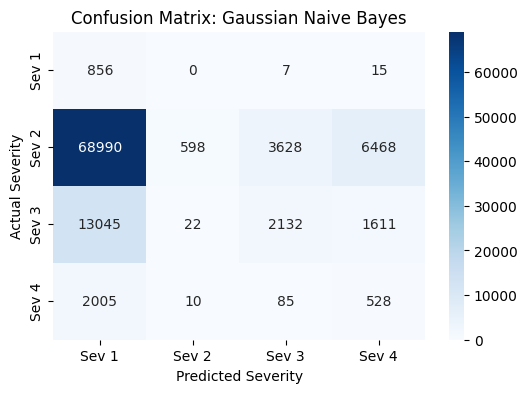

In [10]:
# --- 4. Decision Tree ---
print("Training Decision Tree...")
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_smote, y_train_smote)
dt_preds = dt.predict(X_test)
dt_probs = dt.predict_proba(X_test) # We need probabilities for AUC-ROC

evaluate_model("Decision Tree", y_test, dt_preds, dt_probs)

# --- 5. Gaussian Naive Bayes ---
print("\nTraining Gaussian Naive Bayes...")
nb = GaussianNB()
nb.fit(X_train_smote, y_train_smote)
nb_preds = nb.predict(X_test)
nb_probs = nb.predict_proba(X_test)

evaluate_model("Gaussian Naive Bayes", y_test, nb_preds, nb_probs)


UPDATING ORIGINAL MODELS WITH NEW METRICS

--- Logistic Regression Evaluation ---

1. Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           1       0.04      0.42      0.08       878
           2       0.85      0.66      0.74     79684
           3       0.36      0.42      0.39     16810
           4       0.09      0.35      0.14      2628

    accuracy                           0.61    100000
   macro avg       0.34      0.46      0.34    100000
weighted avg       0.74      0.61      0.66    100000

2. AUC-ROC Score: 0.7309

3. Confusion Matrix:


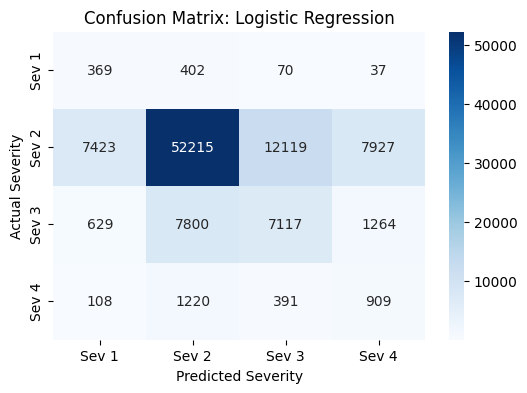


--- Random Forest Evaluation ---

1. Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           1       0.33      0.21      0.25       878
           2       0.90      0.90      0.90     79684
           3       0.60      0.63      0.61     16810
           4       0.32      0.23      0.27      2628

    accuracy                           0.83    100000
   macro avg       0.53      0.49      0.51    100000
weighted avg       0.83      0.83      0.83    100000

2. AUC-ROC Score: 0.8860

3. Confusion Matrix:


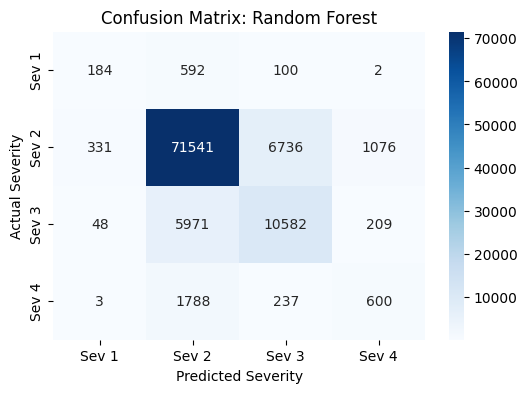


--- XGBoost Evaluation ---

1. Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           1       0.14      0.40      0.21       878
           2       0.89      0.87      0.88     79684
           3       0.59      0.60      0.60     16810
           4       0.24      0.24      0.24      2628

    accuracy                           0.80    100000
   macro avg       0.47      0.53      0.48    100000
weighted avg       0.82      0.80      0.81    100000

2. AUC-ROC Score: 0.8839

3. Confusion Matrix:


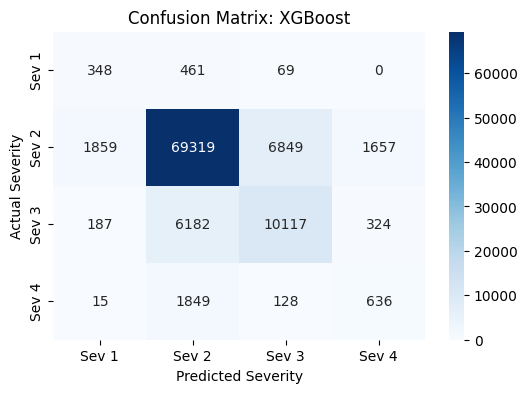

In [11]:
print("\n" + "="*50)
print("UPDATING ORIGINAL MODELS WITH NEW METRICS")
print("="*50)

# --- 1. Logistic Regression Update ---
# We use predict_proba() to get the percentage confidence for the AUC-ROC score
lr_probs = lr.predict_proba(X_test)
evaluate_model("Logistic Regression", y_test, lr_preds, lr_probs)

# --- 2. Random Forest Update ---
rf_probs = rf.predict_proba(X_test)
evaluate_model("Random Forest", y_test, rf_preds, rf_probs)

# --- 3. XGBoost Update ---
xgb_probs = xgb.predict_proba(X_test)
evaluate_model("XGBoost", y_test, xgb_preds, xgb_probs)

In [12]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Re-split X and y temporarily just to count the "Before SMOTE" values
_, _, y_train_temp, _ = train_test_split(X, y, test_size=0.2, random_state=42)

print("=== CLASS DISTRIBUTION BEFORE SMOTE (Training Data) ===")
print(y_train_temp.value_counts().sort_index())
print(f"Total instances before SMOTE: {len(y_train_temp)}\n")

# Now check the values after SMOTE (these are already saved in memory as y_train_smote)
print("=== CLASS DISTRIBUTION AFTER SMOTE (Training Data) ===")
print(y_train_smote.value_counts().sort_index())
print(f"Total instances after SMOTE: {len(y_train_smote)}\n")

# Clean up the temporary variable to keep your RAM free
del y_train_temp

=== CLASS DISTRIBUTION BEFORE SMOTE (Training Data) ===
Severity
1      3478
2    318366
3     67500
4     10656
Name: count, dtype: int64
Total instances before SMOTE: 400000

=== CLASS DISTRIBUTION AFTER SMOTE (Training Data) ===
Severity
1    318366
2    318366
3    318366
4    318366
Name: count, dtype: int64
Total instances after SMOTE: 1273464



In [16]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import gc

print("--- HYBRID SAMPLING STRATEGY ---")

# --- THE FIX: Recreate the data since we deleted it from memory earlier! ---
print("Step 0: Re-splitting the data...")
X = df.drop('Severity', axis=1)
y = df['Severity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# --------------------------------------------------------------------------

print("\nStep 1: Checking original class distribution...")
class_counts = y_train.value_counts()
print(class_counts)

# Dynamically cap massive classes at 100,000
under_strategy = {c: min(100000, count) for c, count in class_counts.items()}

print("\nStep 2: Downsampling the majority class to 100,000...")
under_sampler = RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)
X_train_under, y_train_under = under_sampler.fit_resample(X_train, y_train)

print("\nStep 3: Applying SMOTE to balance the remaining classes...")
smote = SMOTE(random_state=42)
X_train_hybrid, y_train_hybrid = smote.fit_resample(X_train_under, y_train_under)

print("\nFinal Class distribution after Hybrid Sampling:")
print(y_train_hybrid.value_counts())

# Clean up temporary memory so Colab doesn't crash
del X_train
del y_train
del X_train_under
del y_train_under
gc.collect()

--- HYBRID SAMPLING STRATEGY ---
Step 0: Re-splitting the data...

Step 1: Checking original class distribution...
Severity
2    318366
3     67500
4     10656
1      3478
Name: count, dtype: int64

Step 2: Downsampling the majority class to 100,000...

Step 3: Applying SMOTE to balance the remaining classes...

Final Class distribution after Hybrid Sampling:
Severity
1    100000
2    100000
3    100000
4    100000
Name: count, dtype: int64


21732

Training Random Forest on HYBRID Data (This will be much faster!)...

--- Random Forest (Hybrid Data) Evaluation ---

1. Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           1       0.19      0.38      0.25       878
           2       0.94      0.77      0.85     79684
           3       0.49      0.83      0.62     16810
           4       0.23      0.41      0.30      2628

    accuracy                           0.77    100000
   macro avg       0.46      0.60      0.50    100000
weighted avg       0.84      0.77      0.79    100000

2. AUC-ROC Score: 0.8902

3. Confusion Matrix:


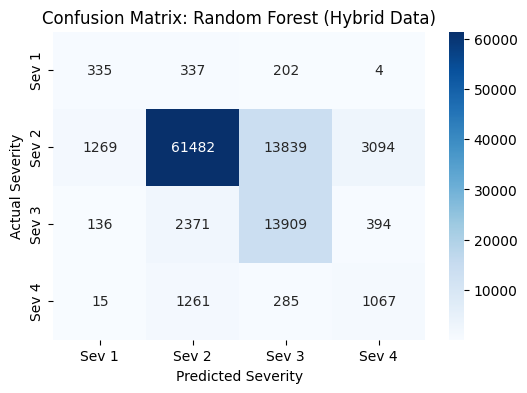

In [17]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest on HYBRID Data (This will be much faster!)...")

# Train on the new, cleaner hybrid data
rf_hybrid = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_hybrid.fit(X_train_hybrid, y_train_hybrid)

# Get predictions and probabilities
rf_hybrid_preds = rf_hybrid.predict(X_test)
rf_hybrid_probs = rf_hybrid.predict_proba(X_test)

# Evaluate using your master function
evaluate_model("Random Forest (Hybrid Data)", y_test, rf_hybrid_preds, rf_hybrid_probs)

Generating Before & After Comparison...

=== FINAL PERFORMANCE TABLE ===


,Metric,Original Model (Pure SMOTE),New Model (Hybrid Sampling)
0,Overall Accuracy,0.8291,0.7679
1,Macro F1-Score,0.5078,0.5040
2,AUC-ROC,0.8860,0.8902
3,Severity 4 Recall (Rarest),0.2283,0.4060


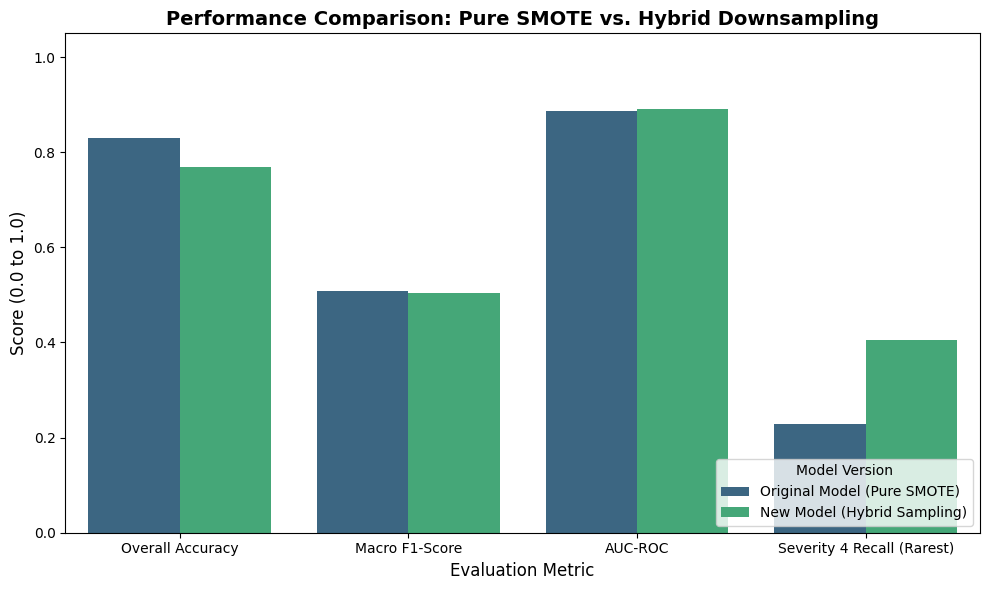

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score
from IPython.display import display

print("Generating Before & After Comparison...\n")

# 1. Calculate metrics for the Original Model (Pure SMOTE)
rf_acc = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds, average='macro')
rf_roc = roc_auc_score(y_test, rf_probs, multi_class='ovr')
rf_rec_4 = recall_score(y_test, rf_preds, labels=[4], average=None)[0] # Extract Severity 4 Recall

# 2. Calculate metrics for the New Model (Hybrid)
hyb_acc = accuracy_score(y_test, rf_hybrid_preds)
hyb_f1 = f1_score(y_test, rf_hybrid_preds, average='macro')
hyb_roc = roc_auc_score(y_test, rf_hybrid_probs, multi_class='ovr')
hyb_rec_4 = recall_score(y_test, rf_hybrid_preds, labels=[4], average=None)[0]

# 3. Build a clean comparison table
comparison_df = pd.DataFrame({
    'Metric': ['Overall Accuracy', 'Macro F1-Score', 'AUC-ROC', 'Severity 4 Recall (Rarest)'],
    'Original Model (Pure SMOTE)': [rf_acc, rf_f1, rf_roc, rf_rec_4],
    'New Model (Hybrid Sampling)': [hyb_acc, hyb_f1, hyb_roc, hyb_rec_4]
})

print("=== FINAL PERFORMANCE TABLE ===")
display(comparison_df.round(4))

# 4. Draw a side-by-side Bar Chart
comparison_melted = comparison_df.melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=comparison_melted, palette='viridis')

# Add styling to the graph
plt.title('Performance Comparison: Pure SMOTE vs. Hybrid Downsampling', fontsize=14, fontweight='bold')
plt.ylim(0, 1.05) # Keep the y-axis standard
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.legend(loc='lower right', title='Model Version')
plt.tight_layout()

# Show the graph!
plt.show()

Generating Feature Importance for the Report...


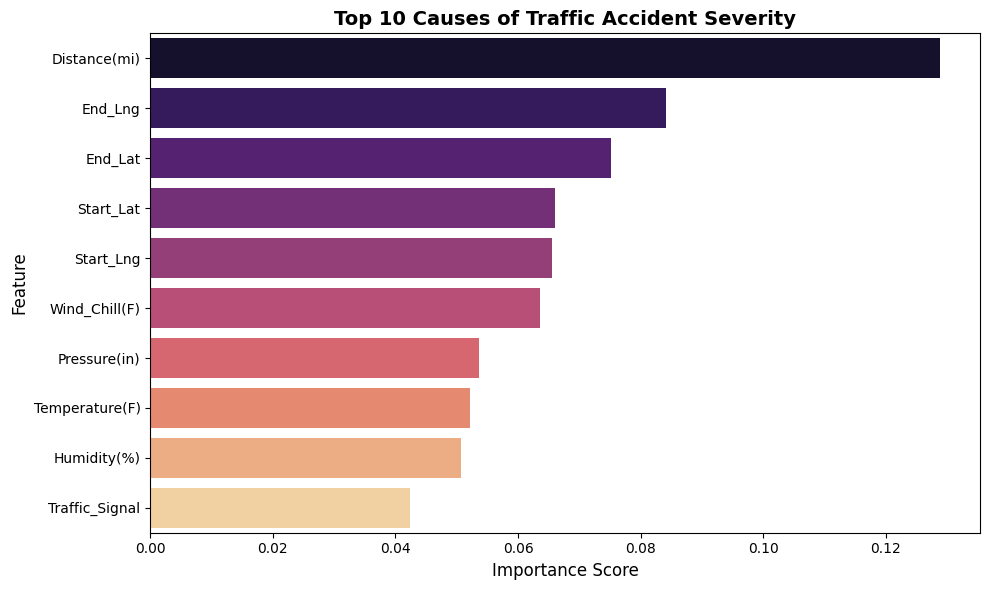

In [20]:
import pandas as pd

print("Generating Feature Importance for the Report...")

# Get the importance scores from your best Hybrid model
importances = rf_hybrid.feature_importances_
feature_names = X_train_hybrid.columns

# Sort them from most to least important
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False).head(10)

# Plot it
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='magma')
plt.title('Top 10 Causes of Traffic Accident Severity', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()